## Бизнес-контекст

Компания теряет около 23% сотрудников в год. Анализ выполнен как если бы его делал аналитик данных в HR-департаменте по запросу руководства: нужно понять, какие факторы статистически связаны с увольнением, проверить гипотезу про зарплату и переработки, и на основе этого дать рекомендации по удержанию персонала.

**В анализе:**
1. Какие признаки сильнее всего коррелируют с увольнением
2. Правда ли, что высокооплачиваемые сотрудники работают больше часов
3. Чем группа уволившихся системно отличается от оставшихся
4. Рекомендации для HR


## **1. Импорт библиотек и загрузка данных**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [4]:
# Глобальная тёмная тема на все графики
import mplcyberpunk
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import LinearSegmentedColormap

plt.style.use("cyberpunk")

In [5]:
df = pd.read_csv('HR.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## **2. Первичный осмотр данных**

In [6]:
print(f"В исходном датасете {df.shape[0]} строк и {df.shape[1]} столбцов")

В исходном датасете 14999 строк и 10 столбцов


In [7]:
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
11598,0.76,0.72,3,263,3,0,0,0,product_mng,medium
5747,0.60,0.81,3,226,2,0,0,0,sales,medium
14039,0.42,0.96,6,173,3,0,0,0,sales,medium
8070,0.92,0.98,4,161,3,0,0,0,technical,medium
4257,0.85,0.86,4,250,3,0,0,0,technical,low


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


В датасете нет пропусков, все столбцы в корректных типах данных

In [9]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [10]:
df.describe(include='object')

,department,salary
count,14999,14999
unique,10,3
top,sales,low
freq,4140,7316


| Признак | Описание |
|---------|----------|
| `satisfaction_level` | уровень удовлетворённости работой (от 0 до 1) |
| `last_evaluation` | время с момента последней оценки в годах |
| `number_project` | количество проектов, выполненных за время работы |
| `average_montly_hours` | среднее количество часов на рабочем месте в месяц |
| `time_spend_company` | стаж работы в компании в годах |
| `Work_accident` | происходили ли несчастные случаи на рабочем месте с сотрудником (1 - да, 0 - нет) |
| `left` | уволился ли сотрудник (1 - да, 0 - нет) |
| `promotion_last_5years ` | повышался ли сотрудник за последние пять лет (1 - да, 0 - нет) |
| `department` | отдел, в котором работает сотрудник |
| `salary` | относительный уровень зарплаты (low / medium / high)|

## **3. Корреляционный анализ**

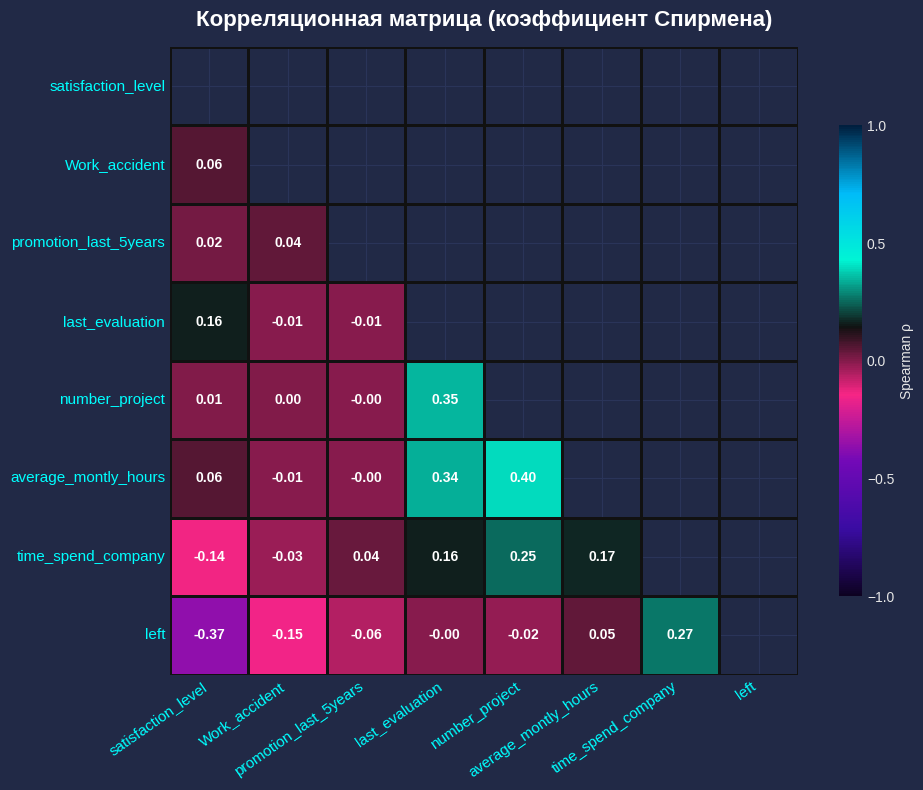

In [11]:
# Признаки
features = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years']

# Корреляция Спирмена
corr = df[features].corr(method="spearman")

# Кластеризация Уорда
link  = linkage(corr, method="ward")
order = leaves_list(link)
corr_ordered = corr.iloc[order, order]

# Маска: нижний треугольник без диагонали
mask = np.triu(np.ones_like(corr_ordered, dtype=bool), k=0)

# Киберпанк-палитра
cmap_custom = LinearSegmentedColormap.from_list(
    "cyberpunk_corr",
    ["#0d0221", "#3a0ca3", "#7209b7", "#f72585",
     "#111111",
     "#00f5d4", "#00bbf9", "#001f3f"],
    N=256,
)

# Матрица
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_ordered, mask=mask, annot=True, fmt=".2f",
    cmap=cmap_custom, center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.8, linecolor="#111",
    cbar_kws={"shrink": 0.75, "label": "Spearman ρ",
              "ticks": [-1, -0.5, 0, 0.5, 1]},
    annot_kws={"size": 10, "color": "white", "weight": "bold"},
    ax=ax,
)

ax.set_title(
    "Корреляционная матрица (коэффициент Спирмена)",
    fontsize=16, fontweight="bold", color="white", pad=15,
)
ax.tick_params(axis="both", labelsize=11, length=0, colors="#cccccc")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right", color="#00ffff")
plt.setp(ax.get_yticklabels(), rotation=0, color="#00ffff")

for spine in ax.spines.values():
    spine.set_edgecolor("#ff00ff")
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

**Топ-2 самые скоррелированные переменные:**

- `average_montly_hours` и `number_project` (r = 0.40 - положительная умеренная связь):

  Среднее количество часов на рабочем месте в месяц растет вместе с количеством проектов, выполненных за время работы.

- `satisfaction_level` и `left` (r = -0.37 - отрицательная умеренная связь):

  Количество уволнений сотрудников растет при снижении уровеня удовлетворённости работой.

**Вывод для бизнеса:** удовлетворённость — не просто метрика самочувствия, а предиктор оттока. Есть смысл отслеживать её в динамике (например, пульс-опросами) и реагировать на просадку заранее, а не по факту увольнения.


**Топ-2 наименее скоррелированные переменные:**

- `number_project` и `promotion_last_5years` (r = 0):

  Нет корреляции между количеством проектов за время работы и повышением сотрудников за последние 5 лет.

- `average_montly_hours` и `promotion_last_5years` (r = 0):

  Нет корреляции между средним количеством часов на рабочем месте в месяц и повышением сотрудников за последние 5 лет.

**Вывод для бизнеса:** нагрузка (число проектов, часы) не связана с тем, повышали сотрудника или нет. Это значит, что повышения в компании выдаются не по признаку количества нагрузки.

Стоит проверить, по какому критерию происходит повышение и прозрачен ли этот процесс для сотрудников.


## **4. Ключевые вопросы EDA**

### **4.1 Cколько сотрудников работает в каждом департаменте**

In [12]:
dept_counts = df['department'].value_counts().sort_values()

print(f"Количество сотрудников по департаментам")
print(dept_counts)

Количество сотрудников по департаментам
department
management      630
hr              739
accounting      767
RandD           787
marketing       858
product_mng     902
IT             1227
support        2229
technical      2720
sales          4140
Name: count, dtype: int64


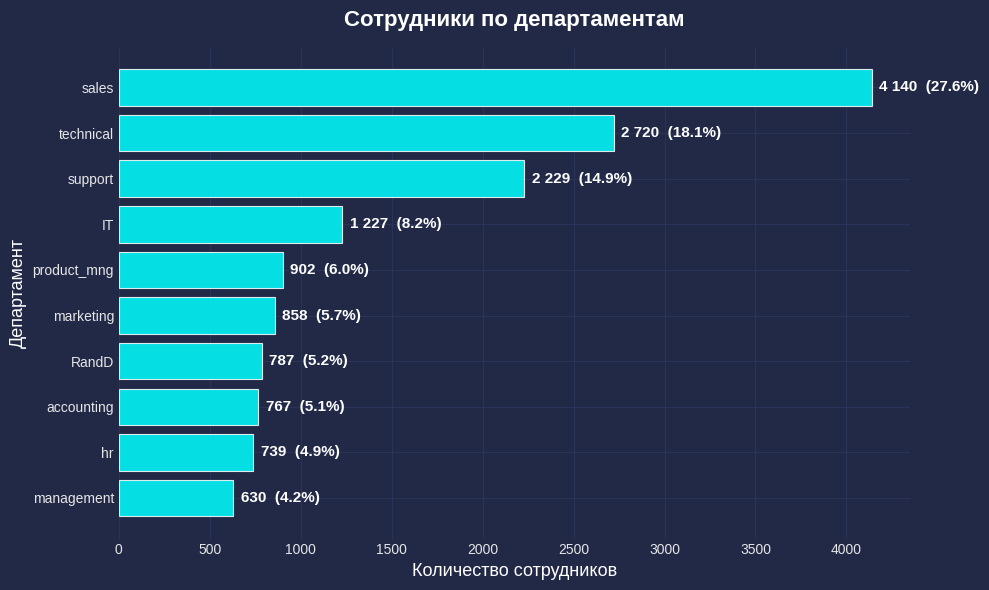

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    dept_counts.index, dept_counts.values,
    color="#00ffff", alpha=0.85, edgecolor="white", linewidth=0.8,
)

total = dept_counts.sum()

# Подписи: абсолютное число + доля в %
for bar, v in zip(bars, dept_counts.values):
    pct = v / total * 100
    ax.text(
        v + dept_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{v:,}  ({pct:.1f}%)".replace(",", " "),
        va="center", ha="left",
        color="#ffffff", fontsize=11, fontweight="bold",
    )

ax.set_xlabel("Количество сотрудников", fontsize=13, color="white")
ax.set_ylabel("Департамент", fontsize=13, color="white")
ax.set_title(
    "Сотрудники по департаментам",
    fontsize=16, fontweight="bold", color="white", pad=15,
)

plt.tight_layout()
plt.show()

### **4.2 Распределение сотрудников по зарплатам**

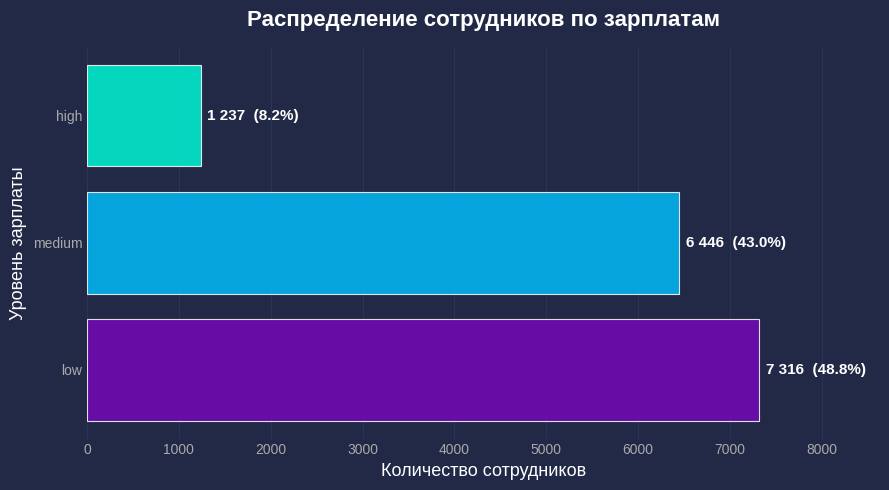

In [14]:
salary_counts = df['salary'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))

# Цвета: тёмный → неон, от низкой зарплаты к высокой
colors = ['#7209b7', '#00bbf9', '#00f5d4']

bars = ax.barh(
    salary_counts.index, salary_counts.values,
    color=colors, alpha=0.85, edgecolor="white", linewidth=0.8,
)

for bar, v in zip(bars, salary_counts.values):
    pct = v / salary_counts.sum() * 100
    ax.text(
        v + salary_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{v:,}  ({pct:.1f}%)".replace(",", " "),
        va="center", ha="left",
        color="#ffffff", fontsize=11, fontweight="bold",
    )

ax.set_xlabel("Количество сотрудников", fontsize=13, color="white")
ax.set_ylabel("Уровень зарплаты", fontsize=13, color="white")
ax.set_title(
    "Распределение сотрудников по зарплатам",
    fontsize=16, fontweight="bold", color="white", pad=15,
)
ax.tick_params(colors="#aaaaaa")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, salary_counts.max() * 1.18)

plt.tight_layout()
plt.show()

### **4.3 Распределение сотрудников по зарплатам в каждом департаменте**

In [15]:
# Таблица сопряжённости: строки — департаменты, столбцы — уровни зарплаты
ct = pd.crosstab(df['department'], df['salary'])

# Доли внутри каждого департамента (по строкам)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

In [16]:
salary_order = ['low', 'medium', 'high']

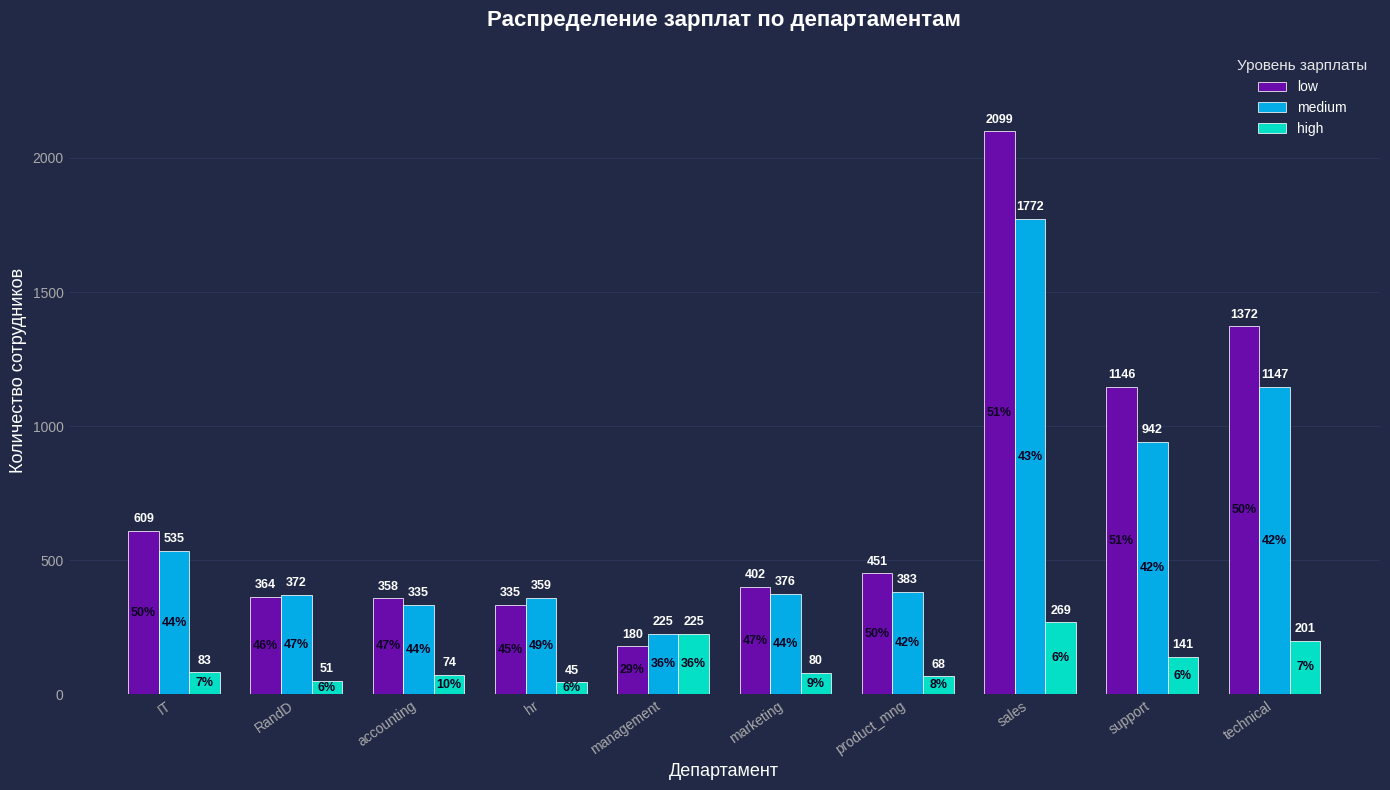

In [17]:
fig, ax = plt.subplots(figsize=(14, 8))

colors = {'low': '#7209b7', 'medium': '#00bbf9', 'high': '#00f5d4'}

x = list(range(len(ct)))
width = 0.25

for i, level in enumerate(salary_order):
    bars = ax.bar(
        [xi + i * width for xi in x],
        ct[level].values,
        width=width,
        color=colors[level], alpha=0.9,
        edgecolor="white", linewidth=0.6,
        label=level,
    )
    # подписи значений
    for bar, v, dept in zip(bars, ct[level].values, ct.index):
        if v == 0:
            continue
        pct = v / ct.loc[dept].sum() * 100

        # число — над баром
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + ct.values.max() * 0.01,
            f"{v}",
            ha="center", va="bottom",
            color="white", fontsize=9, fontweight="bold",
        )
        # процент — внутри бара
        ax.text(
        bar.get_x() + bar.get_width() / 2,
        v * 0.5,
        f"{pct:.0f}%",
        ha="center", va="center",
        color="#0d0221", fontsize=9, fontweight="bold",
        )

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(ct.index, rotation=35, ha="right", color="#00ffff")
ax.set_xlabel("Департамент", fontsize=13, color="white")
ax.set_ylabel("Количество сотрудников", fontsize=13, color="white")
ax.set_title("Распределение зарплат по департаментам", fontsize=16, fontweight="bold", color="white", pad=15)
ax.tick_params(colors="#aaaaaa")
ax.grid(axis="x", visible=False)
ax.legend(title="Уровень зарплаты",
          facecolor="#111", edgecolor="#444", labelcolor="white",
          title_fontsize=11)
ax.set_ylim(0, ct.values.max() * 1.15)

plt.tight_layout()
plt.show()

## **5. Гипотеза: сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом**

**Гипотеза**

**H₀**: среднее average_montly_hours у high ≤ чем у low (высокооплачиваемые работают не больше).

**H₁**: у high больше, чем у low (высокооплачиваемые работают больше).

Уровень значимости: `α = 0.05`


In [18]:
hours_low  = df.loc[df['salary'] == 'low',  'average_montly_hours'].dropna()
hours_high = df.loc[df['salary'] == 'high', 'average_montly_hours'].dropna()

print(f"low:  n = {len(hours_low):4d}  mean = {hours_low.mean():6.2f}  std = {hours_low.std():5.2f}")
print(f"high: n = {len(hours_high):4d}  mean = {hours_high.mean():6.2f}  std = {hours_high.std():5.2f}")

low:  n = 7316  mean = 201.00  std = 50.83
high: n = 1237  mean = 199.87  std = 47.71


In [19]:
# Mann–Whitney U, односторонний: H1 = high > low
u_stat, p_mw = stats.mannwhitneyu(hours_high, hours_low, alternative="greater")
print(f"Mann–Whitney U = {u_stat:.0f},  p-value = {p_mw:.3g}")

alpha = 0.05
verdict = "ОТВЕРГАЕМ H0" if p_mw < alpha else "НЕ отвергаем H0"
print(f"\nα = {alpha}.  {verdict}: высокооплачиваемые работают "
      f"{'больше' if p_mw < alpha else 'не больше'} статистически значимо.")

Mann–Whitney U = 4507096,  p-value = 0.588

α = 0.05.  НЕ отвергаем H0: высокооплачиваемые работают не больше статистически значимо.


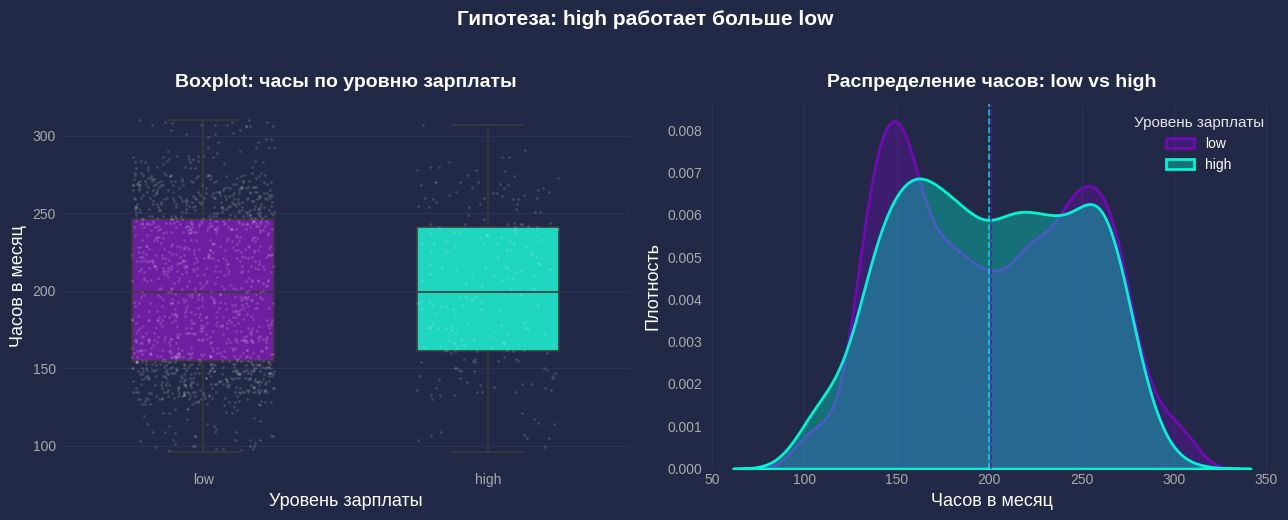

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Слева: boxplot + точки
ax = axes[0]
sns.boxplot(
    data=df[df['salary'].isin(['low', 'high'])],
    x='salary', y='average_montly_hours', hue='salary',
    order=['low', 'high'],
    palette={'low': '#7209b7', 'high': '#00f5d4'},
    width=0.5, linewidth=1.2,
    fliersize=0, legend=False,
    ax=ax,
)
sns.stripplot(
    data=df[df['salary'].isin(['low', 'high'])].sample(1500, random_state=0),
    x='salary', y='average_montly_hours',
    order=['low', 'high'],
    color='white', alpha=0.15, size=2, jitter=0.25, ax=ax,
)
ax.set_xlabel("Уровень зарплаты", fontsize=13, color="white")
ax.set_ylabel("Часов в месяц", fontsize=13, color="white")
ax.set_title("Boxplot: часы по уровню зарплаты", fontsize=14, fontweight="bold", color="white", pad=12)
ax.tick_params(colors="#aaaaaa")
ax.grid(axis="x", visible=False)

# Справа: KDE
ax = axes[1]
sns.kdeplot(hours_low,  ax=ax, color='#7209b7', fill=True, alpha=0.35, linewidth=2, label='low')
sns.kdeplot(hours_high, ax=ax, color='#00f5d4', fill=True, alpha=0.35, linewidth=2, label='high')
ax.axvline(hours_low.mean(),  color='#7209b7', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axvline(hours_high.mean(), color='#00f5d4', linestyle='--', linewidth=1.2, alpha=0.8)

ax.set_xlabel("Часов в месяц", fontsize=13, color="white")
ax.set_ylabel("Плотность", fontsize=13, color="white")
ax.set_title("Распределение часов: low vs high", fontsize=14, fontweight="bold", color="white", pad=12)
ax.tick_params(colors="#aaaaaa")
ax.grid(axis="y", visible=False)
ax.legend(title="Уровень зарплаты",
          facecolor="#111", edgecolor="#444", labelcolor="white",
          title_fontsize=11)

fig.suptitle(f"Гипотеза: high работает больше low", fontsize=15, fontweight="bold", color="white", y=1.03,)
plt.tight_layout()
plt.show()

По результатам статистического теста - нет достаточных данных утверждать, что сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом. Гипотеза отклонена.

**Вывод для бизнеса:** зарплата сама по себе не объясняет переработки — высокооплачиваемые не работают статистически значимо больше низкооплачиваемых.

Причины высоких зарплат стоит искать в другом месте (распределение задач, менеджмент проектов).


## **6. Ключевые показатели уволившихся и не уволившихся сотрудников**

В данном блоке рассмотрены показатели уволившихся и не уволившихся сотрудников:
1. Доля сотрудников с повышением за последние 5 лет
2. Средняя степень удовлетворенности
3. Среднее количество проектов

In [21]:
left_yes = df[df['left'] == 1]
left_no  = df[df['left'] == 0]

print(f"Уволившиеся:      n = {len(left_yes):5d}  ({len(left_yes)/len(df)*100:.1f}%)")
print(f"Оставшиеся:       n = {len(left_no):5d}  ({len(left_no)/len(df)*100:.1f}%)")

Уволившиеся:      n =  3571  (23.8%)
Оставшиеся:       n = 11428  (76.2%)


In [22]:
def describe_group(sub, name):
    return {
        "Группа": name,
        "n": len(sub),
        "Доля с повышением, %": sub['promotion_last_5years'].mean() * 100,
        "Средняя удовлетворённость": sub['satisfaction_level'].mean(),
        "Среднее число проектов": sub['number_project'].mean(),
    }

summary = pd.DataFrame([
    describe_group(left_yes, "Уволившиеся (left=1)"),
    describe_group(left_no,  "Оставшиеся (left=0)"),
]).set_index("Группа")

print(summary.round(3))

                          n  Доля с повышением, %  Средняя удовлетворённость  \
Группа                                                                         
Уволившиеся (left=1)   3571                 0.532                      0.440   
Оставшиеся (left=0)   11428                 2.625                      0.667   

                      Среднее число проектов  
Группа                                        
Уволившиеся (left=1)                   3.856  
Оставшиеся (left=0)                    3.787  


In [23]:
metrics = {
    "satisfaction_level":    "Удовлетворённость",
    "number_project":        "Количество проектов",
    "promotion_last_5years": "Повышение (0/1)",
}

rows = []
for g, sub in [("Уволившиеся", left_yes), ("Оставшиеся", left_no)]:
    for col, label in metrics.items():
        s = sub[col]
        rows.append({
            "Группа": g,
            "Показатель": label,
            "mean":   s.mean(),
            "median": s.median(),
            "std":    s.std(),
            "min":    s.min(),
            "max":    s.max(),
        })

summary_full = pd.DataFrame(rows).set_index(["Группа", "Показатель"])
print(summary_full.round(3))

                                  mean  median    std   min   max
Группа      Показатель                                           
Уволившиеся Удовлетворённость    0.440    0.41  0.264  0.09  0.92
            Количество проектов  3.856    4.00  1.818  2.00  7.00
            Повышение (0/1)      0.005    0.00  0.073  0.00  1.00
Оставшиеся  Удовлетворённость    0.667    0.69  0.217  0.12  1.00
            Количество проектов  3.787    4.00  0.980  2.00  6.00
            Повышение (0/1)      0.026    0.00  0.160  0.00  1.00


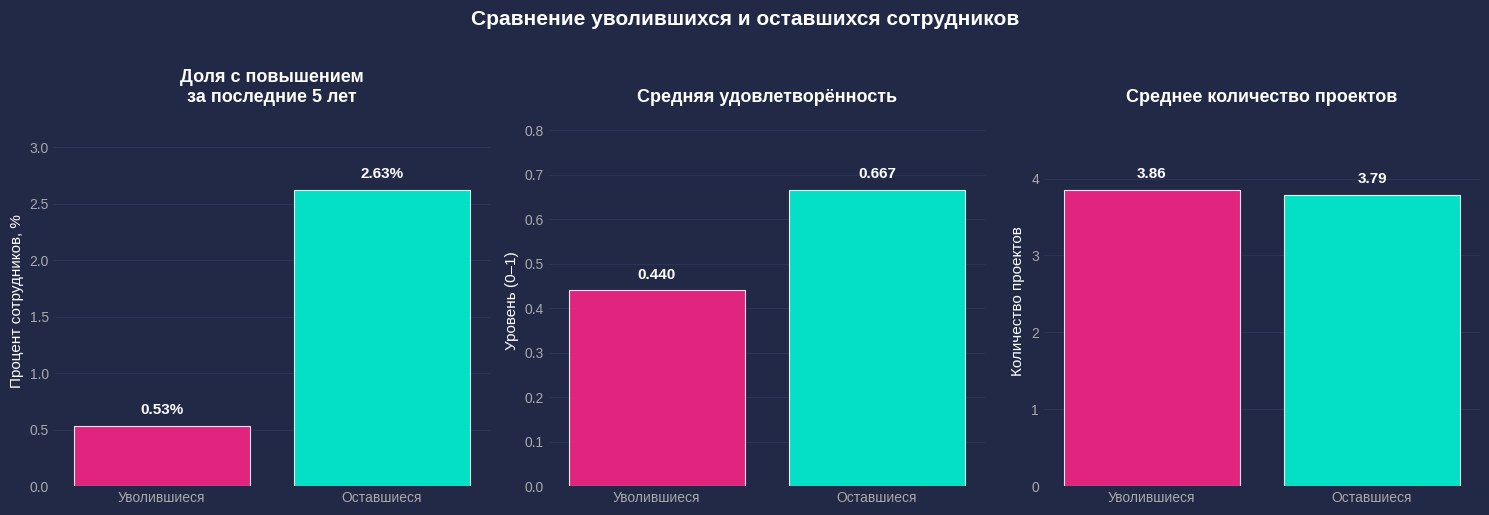

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

groups   = ["Уволившиеся", "Оставшиеся"]
palette  = ["#f72585", "#00f5d4"]    # розовый — ушли, бирюзовый — остались

# Доля с повышением
ax = axes[0]
vals = [left_yes['promotion_last_5years'].mean() * 100, left_no['promotion_last_5years'].mean()  * 100]
bars = ax.bar(groups, vals, color=palette, alpha=0.9, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.03,
            f"{v:.2f}%", ha="center", va="bottom",
            color="white", fontsize=11, fontweight="bold")
ax.set_title("Доля с повышением\nза последние 5 лет", fontsize=13, fontweight="bold", color="white", pad=10)
ax.set_ylabel("Процент сотрудников, %", fontsize=11, color="white")
ax.tick_params(colors="#aaaaaa")
ax.grid(axis="x", visible=False)
ax.set_ylim(0, max(vals)*1.25)

# Средняя удовлетворённость
ax = axes[1]
vals = [left_yes['satisfaction_level'].mean(), left_no['satisfaction_level'].mean()]
bars = ax.bar(groups, vals, color=palette, alpha=0.9, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.03,
            f"{v:.3f}", ha="center", va="bottom",
            color="white", fontsize=11, fontweight="bold")
ax.set_title("Средняя удовлетворённость", fontsize=13, fontweight="bold", color="white", pad=10)
ax.set_ylabel("Уровень (0–1)", fontsize=11, color="white")
ax.tick_params(colors="#aaaaaa")
ax.grid(axis="x", visible=False)
ax.set_ylim(0, max(vals)*1.25)

# Среднее число проектов
ax = axes[2]
vals = [left_yes['number_project'].mean(), left_no['number_project'].mean()]
bars = ax.bar(groups, vals, color=palette, alpha=0.9, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.03,
            f"{v:.2f}", ha="center", va="bottom",
            color="white", fontsize=11, fontweight="bold")
ax.set_title("Среднее количество проектов", fontsize=13, fontweight="bold", color="white", pad=10)
ax.set_ylabel("Количество проектов", fontsize=11, color="white")
ax.tick_params(colors="#aaaaaa")
ax.grid(axis="x", visible=False)
ax.set_ylim(0, max(vals)*1.25)

fig.suptitle("Сравнение уволившихся и оставшихся сотрудников",
             fontsize=15, fontweight="bold", color="white", y=1.02)
plt.tight_layout()
plt.show()

**Разница показателей у оставшихся и уволившихся сотрудников**

**Удовлетворённость**

  Оставшиеся заметно более довольны: 0.667 против 0.44 у уволившихся.

**Наличие повышения**

  У оставшихся — 2.6%, у уволившихся — 0.5%.

**Количество проектов**

  У оставшихся в среднем 3.79, у уволившихся — 3.86.

Эти различия — основа для рекомендаций ниже.


## 7. Executive Summary и рекомендации

**Ключевые находки:**

- Удовлетворённость — главный маркер риска увольнения (0.44 у уволившихся против 0.67 у оставшихся; Spearman r = −0.37 с `left`).
- Гипотеза «высокооплачиваемые работают больше» статистически не подтвердилась (Mann-Whitney, p = 0.588).
- Повышения — не работающий инструмент удержания в текущем виде: их частота крайне низкая в обеих группах (0.53% vs 2.6%).
- Количество проектов почти не различает группы (3.86 vs 3.79) — сама по себе загрузка задачами не объясняет уход.

**Рекомендации:**

1. **Мониторинг удовлетворённости.** Ввести регулярные пульс-опросы и триггер для HR-менеджера при просадке `satisfaction_level` ниже ~0.5 — это самый сильный ранний сигнал риска ухода.
2. **Не считать зарплату единственным рычагом удержания.** Раз оплата не объясняет переработки и слабо связана с оттоком напрямую, проблему стоит искать в содержании работы и климате в команде, а не только повышать оклады.
3. **Пересмотреть практику повышений.** Их частота настолько низкая, что сейчас это не работает как инструмент удержания — стоит проверить прозрачность и критерии карьерного роста.
4. **Приоритизировать крупные отделы** (sales, technical, support) при внедрении программ удержания — там сосредоточен наибольший объём сотрудников и, соответственно, наибольший абсолютный риск потерь.

**Ограничения анализа:**

- Корреляция не равна причинности.
- Датасет исторический, без текстовых причин увольнения (exit-интервью).
- Зарплата дана в категориях (low/medium/high), а не в абсолютных числах.
